# Indian Institute of Information Technology Raichur

**Course:** Deep Learning for Medical Imaging  
**Name:** Shiva Prasad Rao
**Roll No:** CS23B1027

## Project
**Title:** Classification of the BUSI Dataset

In [76]:
import numpy as np
import os
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [77]:
dataset_path = "/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

image_files = []
labels = []

for class_name in ['benign', 'malignant', 'normal']:
    class_path = os.path.join(dataset_path, class_name)
    for filename in os.listdir(class_path):
        image_files.append(os.path.join(class_path, filename))
        labels.append(class_name)

labels = np.array(labels)

In [78]:
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Convert to one-hot
labels_categorical = to_categorical(labels_encoded, num_classes=3)

print(label_encoder.classes_)

['benign' 'malignant' 'normal']


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    image_files,
    labels_categorical,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

In [80]:
def load_preprocess_image(path):
    img = Image.open(path)
    img = img.resize((150, 150))
    img = img.convert('L')  # grayscale
    img = np.array(img)
    img = img.reshape(150, 150, 1)
    img = img.astype('float32') / 255.0
    return img

X_train = np.array([load_preprocess_image(p) for p in X_train])
X_test  = np.array([load_preprocess_image(p) for p in X_test])

y_train = np.array(y_train)
y_test  = np.array(y_test)

print(X_train.shape, y_train.shape)

(1262, 150, 150, 1) (1262, 3)


In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(GlobalAveragePooling2D())   # 🔥 FIXED (better than Flatten)

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.5172 - loss: 1.0250 - val_accuracy: 0.5433 - val_loss: 0.9923
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5897 - loss: 0.9552 - val_accuracy: 0.5433 - val_loss: 0.9869
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5802 - loss: 0.9166 - val_accuracy: 0.5748 - val_loss: 0.8634
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6466 - loss: 0.8092 - val_accuracy: 0.6220 - val_loss: 0.7722
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6774 - loss: 0.7570 - val_accuracy: 0.6535 - val_loss: 0.7617
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6874 - loss: 0.7165 - val_accuracy: 0.6535 - val_loss: 0.7266
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6773 - loss: 0.6889 - val_accuracy: 0.6614 - val_loss: 0.7054
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6677 - loss: 0.7078 - val_accuracy: 0.6693 - 

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, Input

dw_model = Sequential([
    
    Input(shape=(150,150,1)),

    SeparableConv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    SeparableConv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    SeparableConv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    SeparableConv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # 🔥 CRITICAL FIX
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

dw_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [87]:
dw_history = dw_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    class_weight={0:1.0, 1:2.5, 2:3.0},   # 🔥 stronger weights
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4919 - loss: 1.5038 - val_accuracy: 0.1811 - val_loss: 1.1279 - learning_rate: 9.0000e-05
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5136 - loss: 1.4560 - val_accuracy: 0.1811 - val_loss: 1.1582 - learning_rate: 9.0000e-05
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5545 - loss: 1.3879 - val_accuracy: 0.1811 - val_loss: 1.2014 - learning_rate: 9.0000e-05
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5606 - loss: 1.4210 - val_accuracy: 0.1811 - val_loss: 1.2655 - learning_rate: 9.0000e-05
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6050 - loss: 1.3761 - val_accuracy: 0.1811 - val_loss: 1.3350 - learning_rate: 2.7000e-05
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6050 - loss: 1.2905 - val_accuracy: 0.1811 - val_loss: 1.4234 - learning_rate: 2.7000e-05


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Confusion Matrix
 [[169   4   6]
 [ 51  29   4]
 [ 19   0  34]]

Classification Report
               precision    recall  f1-score   support

      benign       0.71      0.94      0.81       179
   malignant       0.88      0.35      0.50        84
      normal       0.77      0.64      0.70        53

    accuracy                           0.73       316
   macro avg       0.79      0.64      0.67       316
weighted avg       0.76      0.73      0.71       316



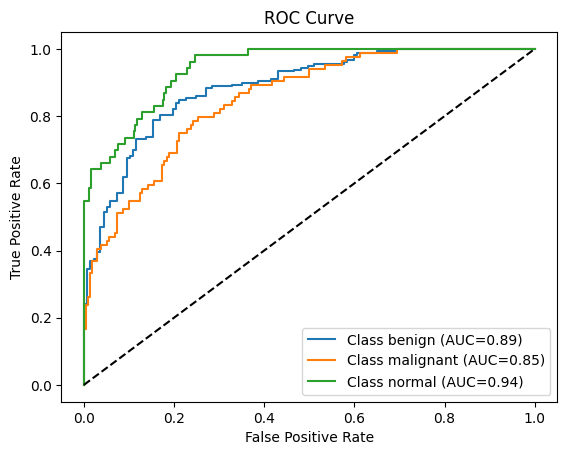

In [89]:
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob=model.predict(X_test)
y_pred=np.argmax(y_pred_prob,axis=1)
y_true=np.argmax(y_test,axis=1)

cm=confusion_matrix(y_true,y_pred)
print("Confusion Matrix\n",cm)

print("\nClassification Report\n",classification_report(y_true,y_pred,target_names=label_encoder.classes_))

y_test_bin=label_binarize(y_true,classes=[0,1,2])
n_classes=3

fpr=dict()
tpr=dict()
roc_auc=dict()

for i in range(n_classes):
    fpr[i],tpr[i],_=roc_curve(y_test_bin[:,i],y_pred_prob[:,i])
    roc_auc[i]=auc(fpr[i],tpr[i])

plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i],tpr[i],label="Class %s (AUC=%0.2f)"%(label_encoder.classes_[i],roc_auc[i]))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Metric                           Standard CNN     DW Sep CNN
Train Accuracy                         0.1688         0.1688
Test  Accuracy                         0.1677         0.1677
Train Loss                             5.6475        18.0407
Test  Loss                             5.6612        18.0589
Trainable Params                      109,571         88,812


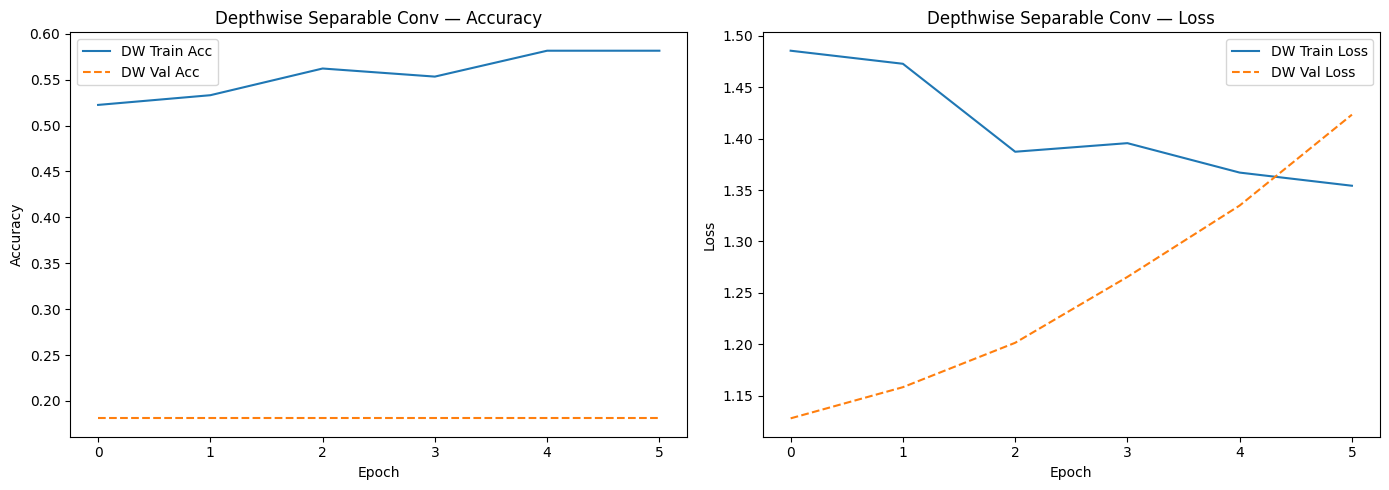

In [92]:
# ============================================================
# Model Comparison: Standard CNN vs Depthwise Separable CNN
# ============================================================
print("=" * 60)
print(f"{'Metric':<30} {'Standard CNN':>14} {'DW Sep CNN':>14}")
print("=" * 60)

std_train_loss, std_train_acc = model.evaluate(X_train, y_train, verbose=0)
std_test_loss,  std_test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print(f"{'Train Accuracy':<30} {std_train_acc:>14.4f} {dw_train_acc:>14.4f}")
print(f"{'Test  Accuracy':<30} {std_test_acc:>14.4f} {dw_test_acc:>14.4f}")
print(f"{'Train Loss':<30} {std_train_loss:>14.4f} {dw_train_loss:>14.4f}")
print(f"{'Test  Loss':<30} {std_test_loss:>14.4f} {dw_test_loss:>14.4f}")
print(f"{'Trainable Params':<30} {model.count_params():>14,} {dw_model.count_params():>14,}")
print("=" * 60)

# Learning curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(dw_history.history['accuracy'],     label='DW Train Acc')
axes[0].plot(dw_history.history['val_accuracy'], label='DW Val Acc',   linestyle='--')
axes[0].set_title('Depthwise Separable Conv — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(dw_history.history['loss'],     label='DW Train Loss')
axes[1].plot(dw_history.history['val_loss'], label='DW Val Loss',   linestyle='--')
axes[1].set_title('Depthwise Separable Conv — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()